**Titanic EDA Analysis (Task 2 B.Y.T.E ArithmaticTech)**
The task focuses on the exploratory analysis of Titanic dataset and finding important relationships between numerical features 
We will go into the following:
1. Data Exploration
2. Data Cleaning
3. Correlation
4. Data Visualizations and Key Insights

**Step 0: Importing Important Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**First: Data Loading and Exploration**

In [2]:
#Loading the dataset
dataset = sns.load_dataset('titanic')

In [3]:
#Exploration of the first 5 rows in the dataset
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
#Exploration of the last 5 rows in the dataset
dataset.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
#Explortion of the information of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
#Exploration of the shape of the dataset
dataset.shape

(891, 15)

In [7]:
#Exploration of the index of the dataset
dataset.index

RangeIndex(start=0, stop=891, step=1)

In [8]:
#Exploration of names of columns in the dataset
dataset.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [9]:
#Exploration of the datatypes of each column in the dataset
dataset_dt = pd.DataFrame({'Column': dataset.columns, 'Data Type': dataset.dtypes}).reset_index().drop('index', axis = 1)
dataset_dt

,Column,Data Type
0,survived,int64
1,pclass,int64
2,sex,object
3,age,float64
4,sibsp,int64
5,parch,int64
6,fare,float64
7,embarked,object
8,class,category
9,who,object


In [10]:
#Exploration of the statistical information in the dataset
dataset.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Second: Data Cleaning**

In [11]:
#Exploration of the sum of null values per each column
dataset.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
#Making null values percentages
null_percentage = ((dataset.isnull().sum(axis = 0) * 100) / len(dataset)).sort_values().reset_index()

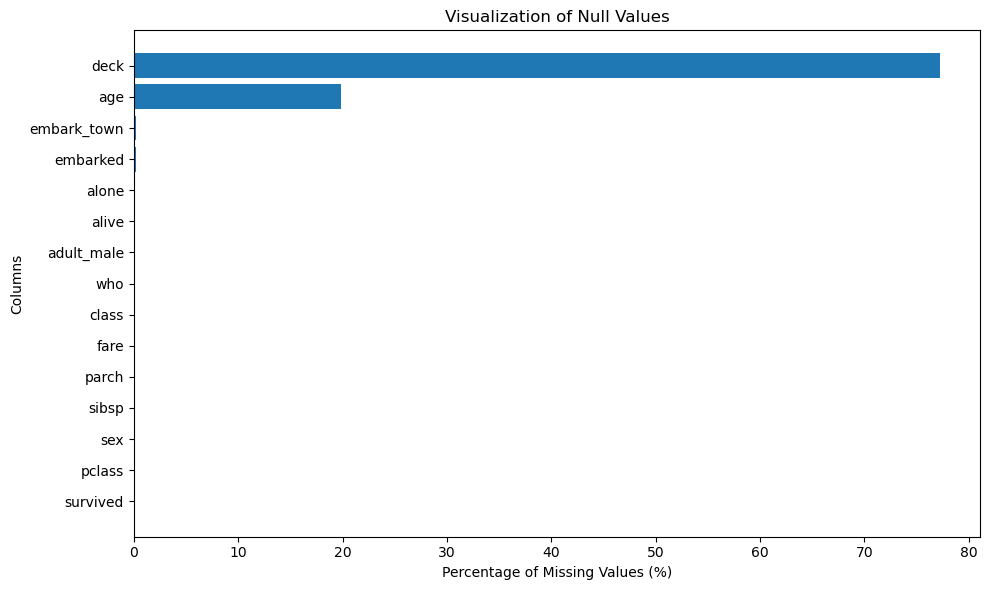

In [13]:
# Visualizing null values 
plt.figure(figsize=(10, 6))
plt.barh(null_percentage['index'], width=null_percentage[0])
plt.title('Visualization of Null Values')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

From this visualization, we conclude that the column of 'deck' is not important because the percentage of null values is more than 50% so, we will drop this 

In [14]:
#Dropping the 'deck' column 
dataset = dataset.drop('deck', axis = 1)

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


In [16]:
#Dropping the rows that contains null ages
dataset = dataset.dropna()

In [17]:
#Checking the sum of null values
dataset.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [18]:
#Exploring duplicates
dataset.duplicated().sum()

np.int64(38)

In [19]:
#Extracting rows that are duplicated
dataset[dataset.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
133,1,2,female,29.00,1,0,26.0000,S,Second,woman,False,Southampton,yes,False
173,0,3,male,21.00,0,0,7.9250,S,Third,man,True,Southampton,no,True
213,0,2,male,30.00,0,0,13.0000,S,Second,man,True,Southampton,no,True
313,0,3,male,28.00,0,0,7.8958,S,Third,man,True,Southampton,no,True
320,0,3,male,22.00,0,0,7.2500,S,Third,man,True,Southampton,no,True
343,0,2,male,25.00,0,0,13.0000,S,Second,man,True,Southampton,no,True
355,0,3,male,28.00,0,0,9.5000,S,Third,man,True,Southampton,no,True
387,1,2,female,36.00,0,0,13.0000,S,Second,woman,False,Southampton,yes,True
418,0,2,male,30.00,0,0,13.0000,S,Second,man,True,Southampton,no,True
476,0,2,male,34.00,1,0,21.0000,S,Second,man,True,Southampton,no,False


In [20]:
#Dropping duplicated rows
dataset = dataset.drop_duplicates()

In [21]:
#Checking the success of operation
dataset.duplicated().sum()

np.int64(0)

In [22]:
#Feature Engineering Part: Creating (family_size) column
dataset['family_size'] = dataset['sibsp'] + dataset['parch'] + 1
dataset

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,Southampton,no,True,1
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False,6
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1


In [23]:
#Creating (is_alone) column
dataset['is_alone'] = (dataset['family_size'] == 1).astype(int)
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1


In [24]:
#Creating (fare_category) column 
labels = ['Small Range', 'Medium Range', 'High Range']

In [25]:
#Defining the maximum and minimum of fares
print("Maximum:", dataset['fare'].max())
print("Minimum:", dataset['fare'].min())

Maximum: 512.3292
Minimum: 0.0


In [29]:
bin_edges = [-0.1, 30.0, 100.0, float("inf")]
dataset['fare_category'] = pd.cut(dataset['fare'], bins = bin_edges, labels = labels)
dataset.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone,fare_category
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0,Small Range
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0,Medium Range
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1,Small Range
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0,Medium Range
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1,Small Range


**Third Part: Correlation**

In [27]:
#Creating correlation variable
df_matrix = dataset.select_dtypes(include = 'number').corr()

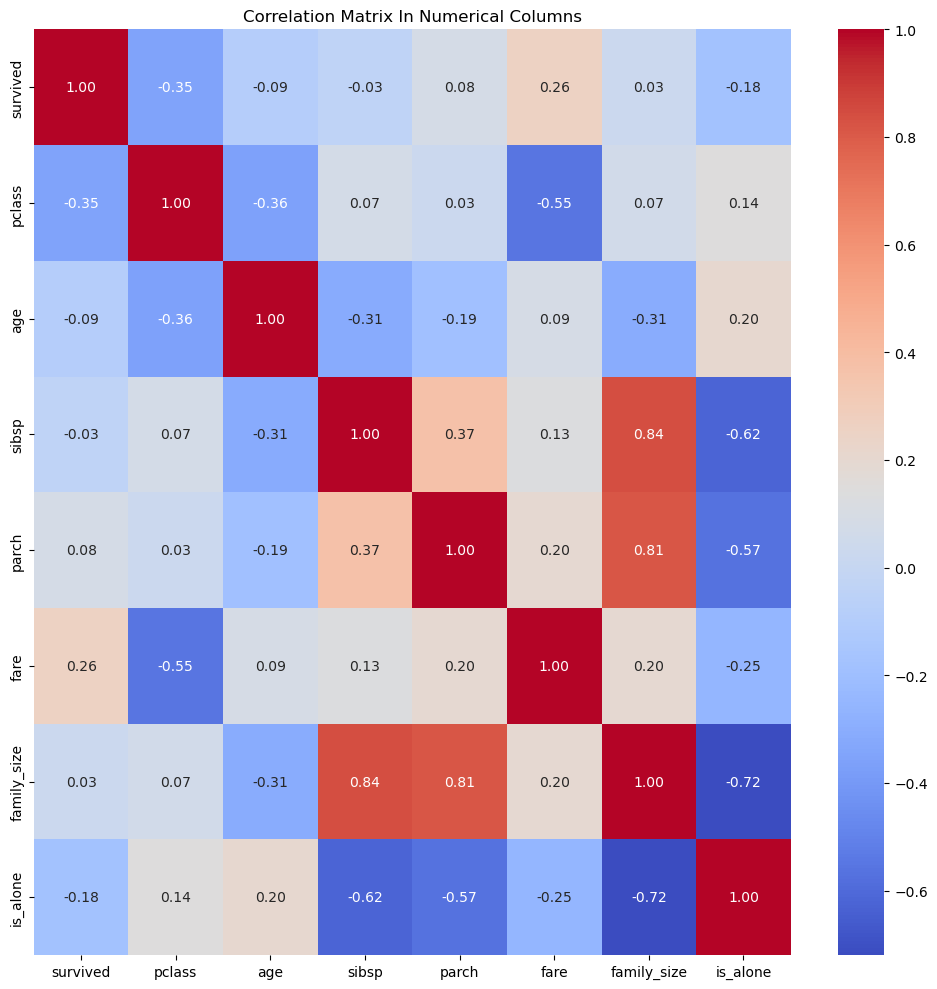

In [28]:
#Visualizing correlation using heatmap
plt.figure(figsize = (10,10))
sns.heatmap(df_matrix, cmap = 'coolwarm', fmt = '.2f', annot = True)
plt.title('Correlation Matrix In Numerical Columns')
plt.tight_layout()
plt.show()

**Explanation of the visualization**

First: In the high positive degree parts, there are 2 strong positive relationships between the following: 
1. 'sibsp' column and 'family_size' column
2. 'parch' column and 'family_size' column

because these 2 columns are highly related to the column 'family_size' which is calculated from these columns

**---------------------------------------------------------------------------------------------------------**

Second: In the high negative degree parts, there are a quite high negative relationship between 'is_alone' column and 'family_size' column
and this shapes that the higher degree of loneliness, the lower size in family

**---------------------------------------------------------------------------------------------------------**

Third: In medium parts, there is an intermediate negative relationship between both 'parch' and 'sibsp' and 'is_alone' and this asserts that the alone person does not include children and parents, and there is an intermediate negative relationship between 'pclass' and 'fare' column and this asserts that the class of a ticket is, quite, related to the fare.

All other relationships are weak.

**Fourth: Data Visualization and Key Insights**

**1: What Is The Highest Class Based On The Percentage Of Survival ?**

In [35]:
#Aggragating the class based on the percentage of survival 
percentage_survival = dataset.groupby('pclass')['survived'].sum().reset_index()
percentage_survival['survived'] = percentage_survival['survived'] / len(dataset) * 100
percentage_survival = percentage_survival.rename(columns = {'survived': 'percentage_survive'})
percentage_survival

,pclass,percentage_survive
0,1,17.655786
1,2,11.721068
2,3,12.314540


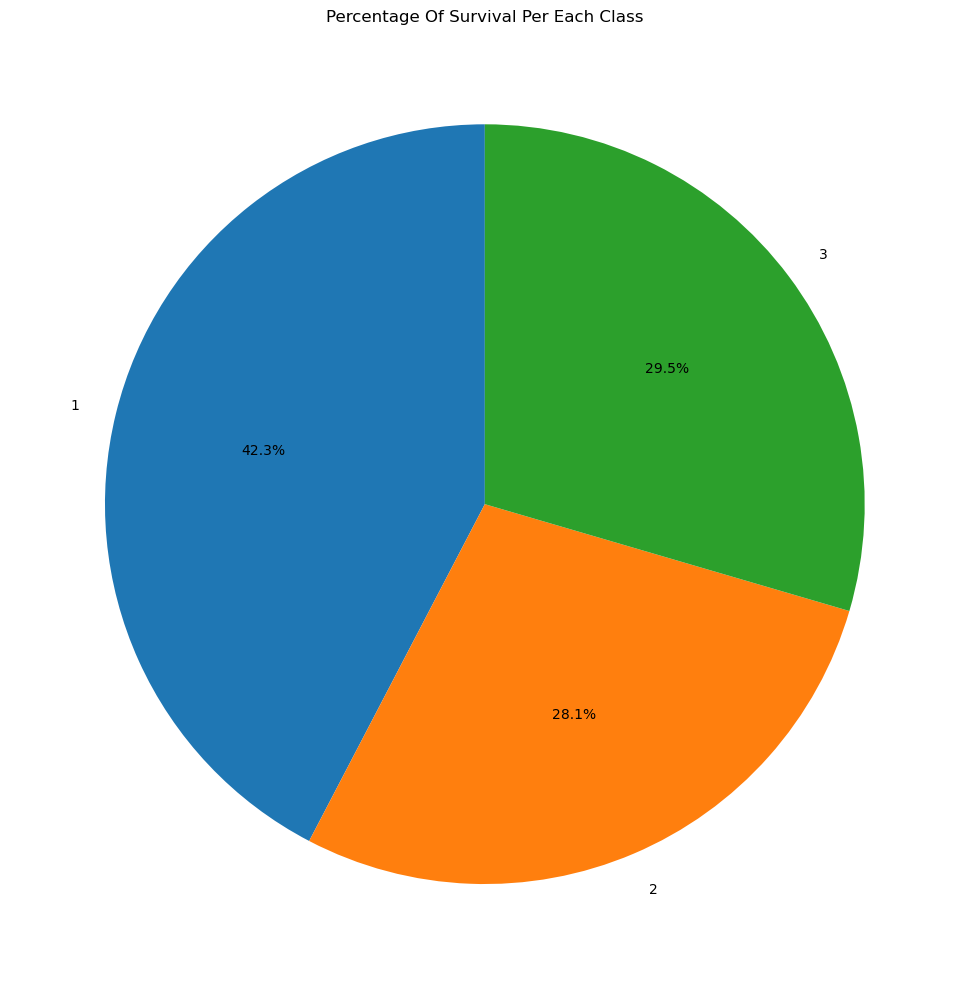

In [36]:
#Plotting a pie plot to this question
plt.figure(figsize = (10,10))
plt.pie(percentage_survival['percentage_survive'], labels = percentage_survival['pclass'], startangle = 90, autopct = '%1.1f%%')
plt.title('Percentage Of Survival Per Each Class')
plt.tight_layout()
plt.show()

**Key Insight To Question 1:**

We concluded that the first class is more to be survived than the other classes because may the first class have more advanced ways to survive than the others like priority access to lifeboats and proximity.
Also, we found that second class is less to be survived because of lower priority and farther location.

**2: What are the ages that is the most common in the titanic boat ?**

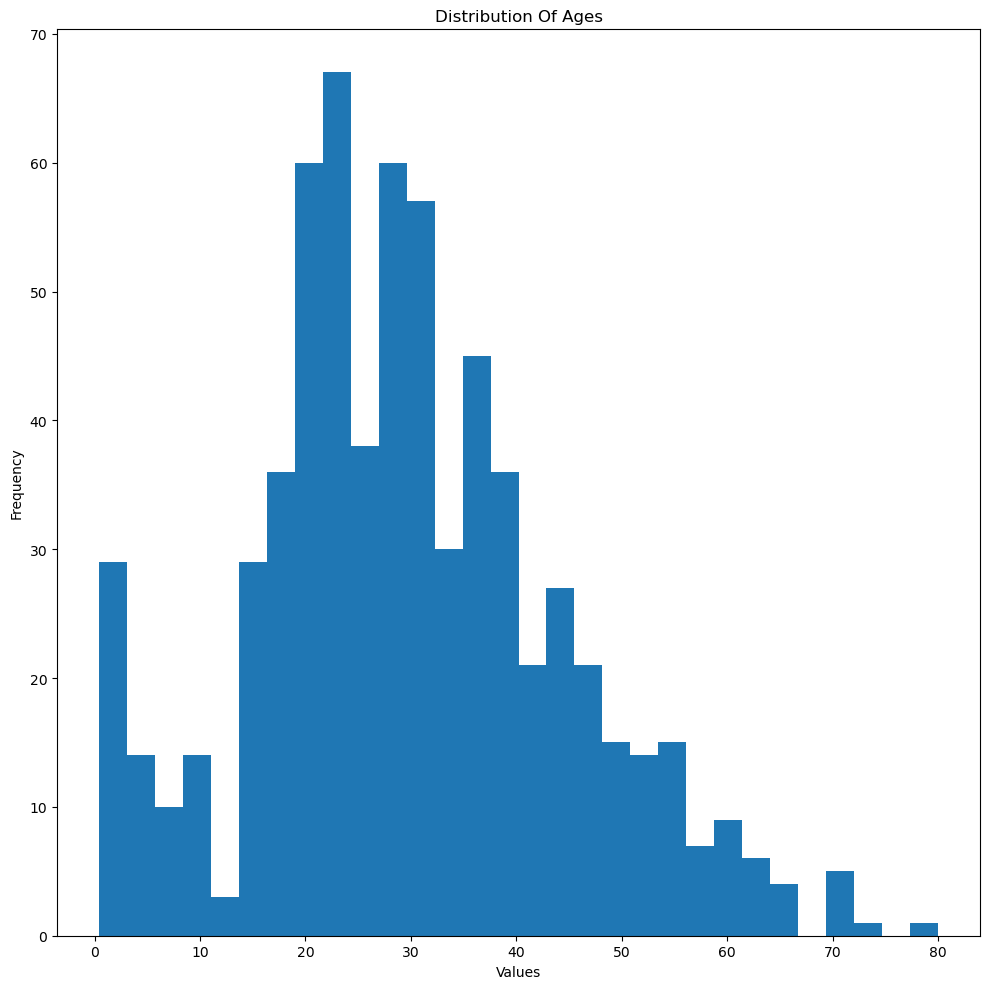

In [37]:
#Plotting a histogram about ages
fig, ax = plt.subplots(figsize = (10,10))
ax.hist(dataset['age'], bins = 30)
ax.set_xlabel('Values')
ax.set_ylabel('Frequency')
ax.set_title('Distribution Of Ages')
plt.tight_layout()
plt.show()

**Key Insight to Question 2:**

The most common ages in the titanic boat is, approximately, between 20 and 35 and asserts that the most passengers are adults and teenagers 

**3: Is to be alone mean that you have to be not survived ?**

In [40]:
#Aggregating the is_alone column based on the average of survival 
alone_survival = dataset.groupby('is_alone')['survived'].mean().reset_index()
alone_survival

,is_alone,survived
0,0,0.514658
1,1,0.335150


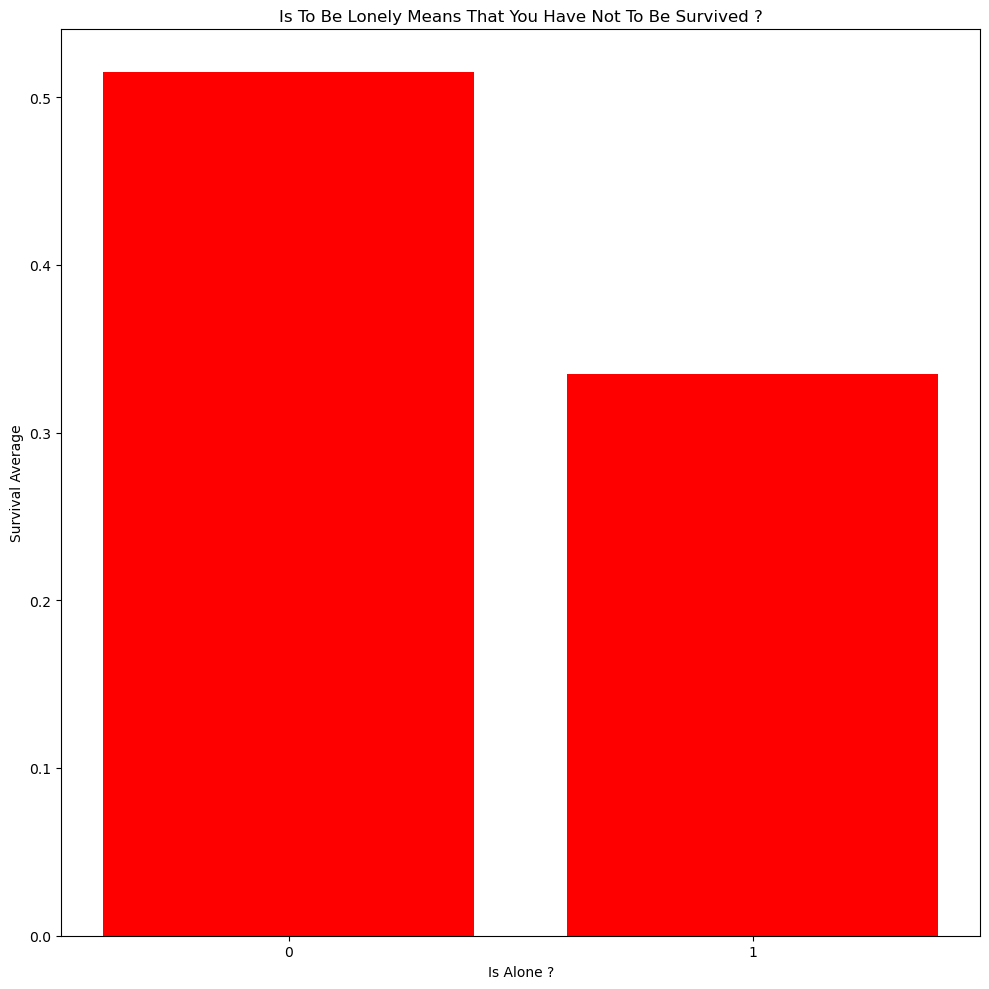

In [43]:
#Plotting a bar plot 
fig, ax = plt.subplots(figsize = (10,10))
ax.bar(alone_survival['is_alone'], height = alone_survival['survived'], color = 'red')
ax.set_title('Is To Be Lonely Means That You Have Not To Be Survived ?')
ax.set_xlabel('Is Alone ?')
ax.set_ylabel('Survival Average')
ax.set_xticks([0, 1])
plt.tight_layout()
plt.show()

**Key Insight To Question 3:**

The following plot represent that to be alone means that you have not to be survived because the rate of survival in not-alone section is higher than the one that repersents on alone section and indeicates that not-alone persons have qualities that increases the chance of survival like collaboration 

**4: What is the embark town that has the greatest profit ?**

In [46]:
#Aggregating the embark town based on the average of fares ? 
embark_profit = dataset.groupby('embark_town')['fare'].mean().sort_values().reset_index()
embark_profit

,embark_town,fare
0,Queenstown,18.265775
1,Southampton,28.521636
2,Cherbourg,68.672042


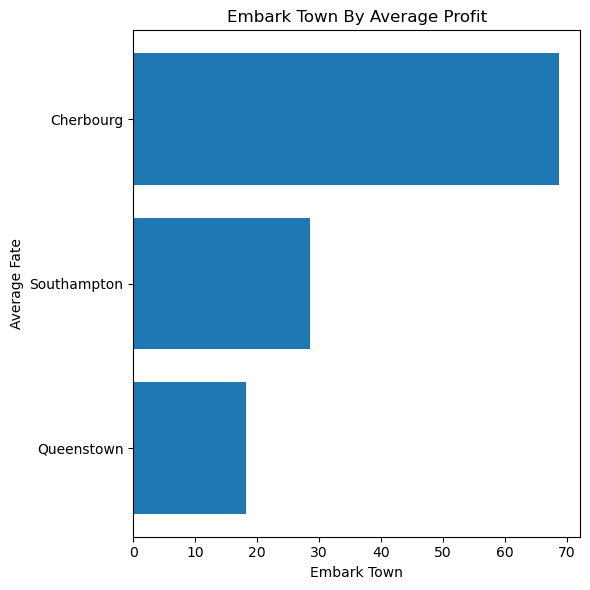

In [48]:
#Plotting the bar horizontal plot
fig, ax = plt.subplots(figsize = (6,6))
ax.barh(embark_profit['embark_town'], width = embark_profit['fare'])
ax.set_title('Embark Town By Average Profit')
ax.set_xlabel('Embark Town')
ax.set_ylabel('Average Fate')
plt.tight_layout()
plt.show()

**Key Insight to Question 4:**

We conclude that the town that has the largest profit is 'Cherbourg' by the rate of $68.7 because of a higher percentage of wealthy first-class passengers.

**-----------------------------------------------------------------------------------Summary------------------------------------------------------------------------------------------**

This exploratory data analysis of the Titanic dataset reveals that socioeconomic status was the primary determinant of survival. First-class passengers achieved significantly higher survival rates due to their proximity to safety and prioritized evacuation access. Additionally, embarkation ports heavily dictated passenger demographics, with Cherbourg exhibiting the highest average ticket fares driven by a concentration of wealthy first-class travelers.